In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("customer_churn_dataset-testing-master.csv")
df = df.drop("CustomerID", axis=1)

# Customer Churn Prediction Using Artificial Neural Networks
## Objective
The goal of this project is to predict whether a customer is likely to churn based on demographic information, subscription details, usage patterns, spending behavior, and customer support interactions.

This project explores:

Exploratory Data Analysis (EDA),
Feature preprocessing,
Classical machine learning baselines,
Artificial Neural Networks (PyTorch),
and Model evaluation and comparison

## EDA
Looking at the data

In [42]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


We have 12 features and 64374 items in each without empty values

In [43]:
df.shape

(64374, 11)

In [44]:
df.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                64374 non-null  int64
 1   Gender             64374 non-null  str  
 2   Tenure             64374 non-null  int64
 3   Usage Frequency    64374 non-null  int64
 4   Support Calls      64374 non-null  int64
 5   Payment Delay      64374 non-null  int64
 6   Subscription Type  64374 non-null  str  
 7   Contract Length    64374 non-null  str  
 8   Total Spend        64374 non-null  int64
 9   Last Interaction   64374 non-null  int64
 10  Churn              64374 non-null  int64
dtypes: int64(8), str(3)
memory usage: 5.4 MB


It seems we have a mean age of 42, mean tenure of 31 years and an avg churn rate of 47%

In [46]:
df.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [47]:
df["Churn"].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

The churn looks reasonably balanced. roughly 47% of churn rate is observed by an avg data.

In [48]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64

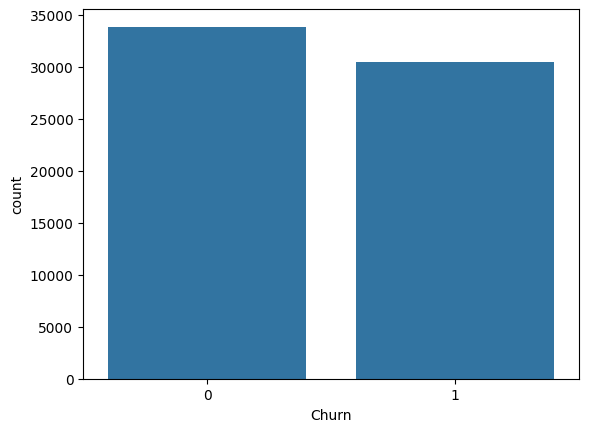

In [49]:
sns.countplot(x="Churn", data=df)
plt.show()

This dataset looks highly synthetic tho.

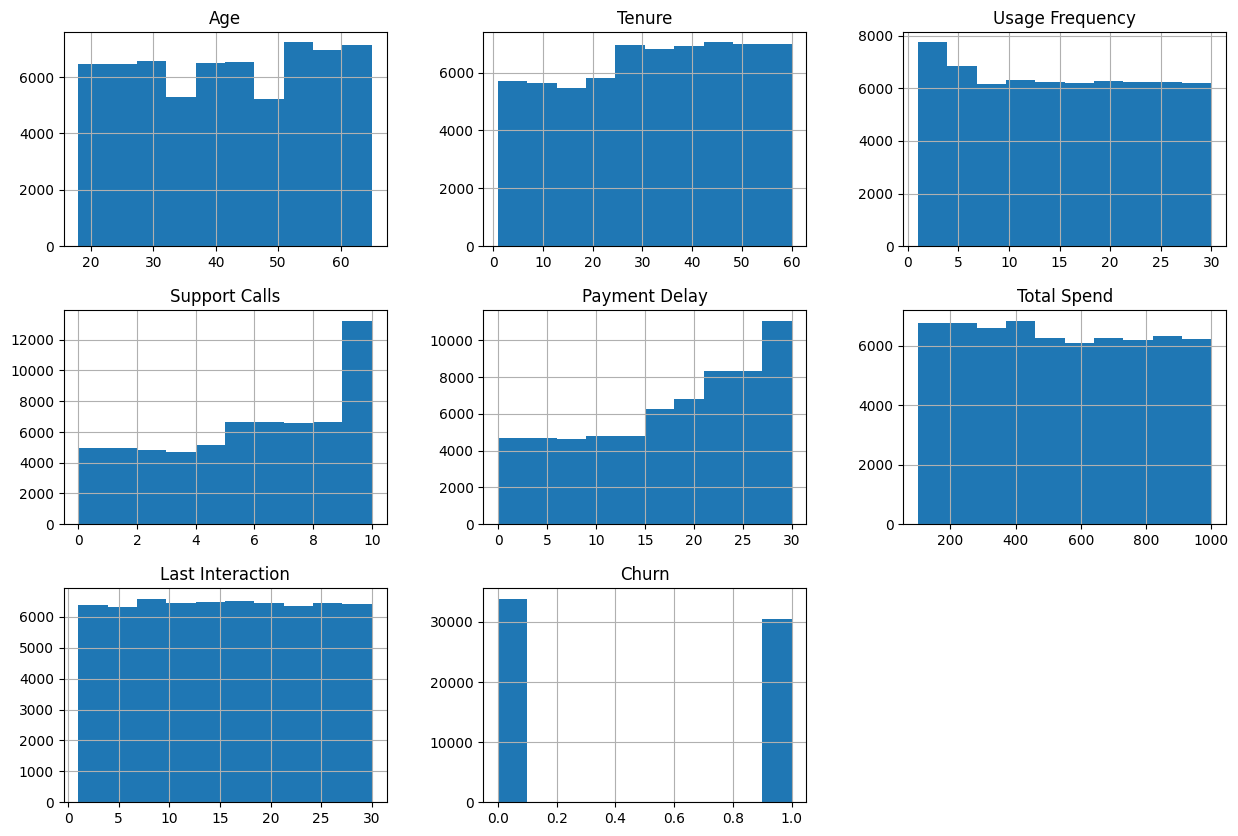

In [50]:
df.hist(figsize=(15,10))
plt.show()

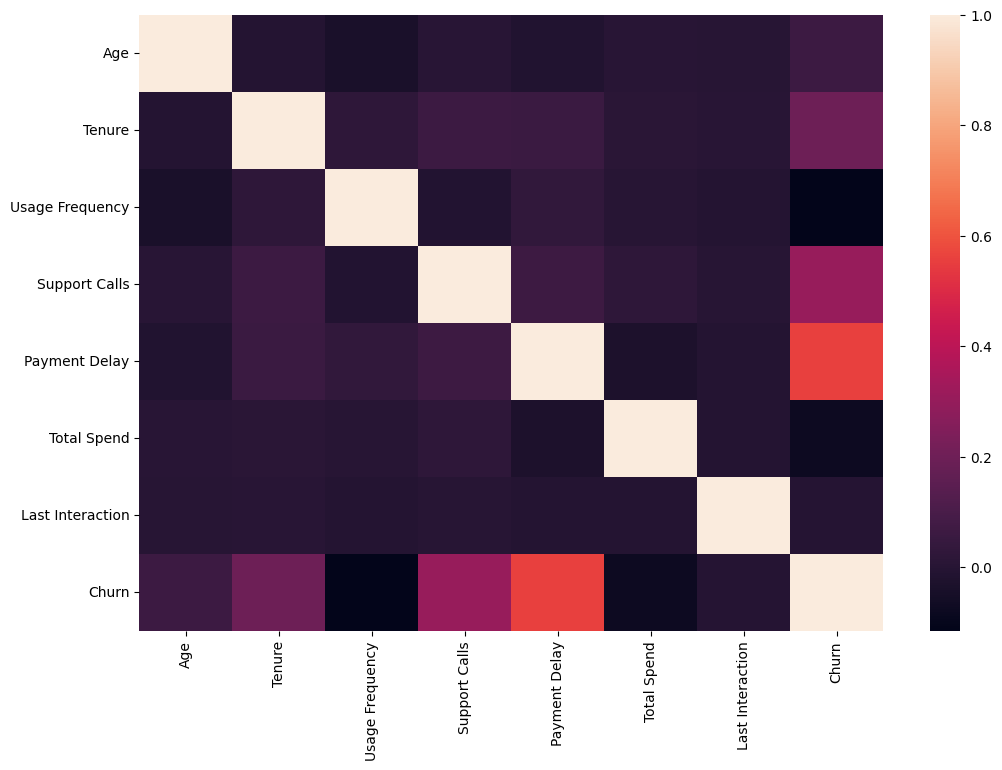

In [51]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr)
plt.show()

We can see that Churn Rate depends decently on Payment delay and Support Calls in comparison to other factors

In [52]:
df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

Churn               1.000000
Payment Delay       0.557386
Support Calls       0.304631
Tenure              0.195327
Age                 0.063457
Last Interaction   -0.002818
Total Spend        -0.078867
Usage Frequency    -0.115098
Name: Churn, dtype: float64

So females had a higher churn rate. Also a higher churn rate for monthly payment mode.

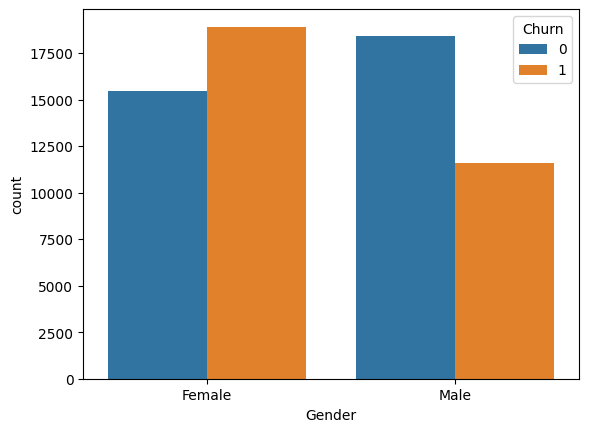

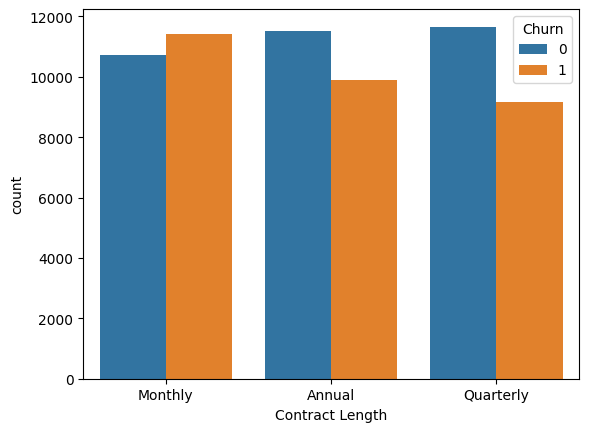

In [53]:
sns.countplot(
    x="Gender",
    hue="Churn",
    data=df
)
plt.show()

sns.countplot(
    x="Contract Length",
    hue="Churn",
    data=df
)
plt.show()

In [54]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

## Data Preprocesseing

In [55]:
#Separate features and labels
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include="object"):
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])


#Encode categoricals
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)


#Scale features
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

/tmp/ipykernel_116554/1875518912.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object"):


Train-test split

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Classical ML Baselines

applying logistic regeression

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


lr = LogisticRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



random forest

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

rf = RandomForestClassifier()

rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.9993009708737864
[[6772    4]
 [   5 6094]]


The confusion matrix is pretty solid so far but our data being "artificial" the model became too well so it overfit.

In [59]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.9999986207505325


Time for XGBoost

In [60]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 1.0
AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



yet again expected from an artificial dataset

# ANN

In [61]:
import torch

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)

y_train_t = torch.FloatTensor(
    y_train.values
).reshape(-1,1)

y_test_t = torch.FloatTensor(
    y_test.values
).reshape(-1,1)

/tmp/ipykernel_116554/2259084801.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  y_train_t = torch.FloatTensor(


In [62]:
import torch.nn as nn

class ChurnNet(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)



In [63]:
model = ChurnNet(X_train.shape[1])

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

Training Loop

In [64]:
epochs = 100

for epoch in range(epochs):

    optimizer.zero_grad()

    outputs = model(X_train_t)

    loss = criterion(
        outputs,
        y_train_t
    )

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:
        print(epoch, loss.item())

0 0.6884135603904724
10 0.6639789342880249
20 0.6282892227172852
30 0.577557384967804
40 0.5177547335624695
50 0.4583226144313812
60 0.406829297542572
70 0.3693549335002899
80 0.3455180823802948
90 0.32855039834976196


In [65]:
with torch.no_grad():

    probs = model(X_test_t)

    preds = (
        probs > 0.5
    ).float()

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds.numpy()
    )
)

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      6776
           1       0.86      0.85      0.85      6099

    accuracy                           0.86     12875
   macro avg       0.86      0.86      0.86     12875
weighted avg       0.86      0.86      0.86     12875



In [66]:
probs

tensor([[0.0381],
        [0.0705],
        [0.0489],
        ...,
        [0.0375],
        [0.7793],
        [0.4070]])

In [67]:
model.eval()

ChurnNet(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

In [68]:
accuracy = (preds == y_test_t).float().mean()

print("Accuracy:", accuracy.item())

Accuracy: 0.8623689413070679


In [69]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_t.numpy(),
    preds.numpy()
)

print(cm)

[[5938  838]
 [ 934 5165]]


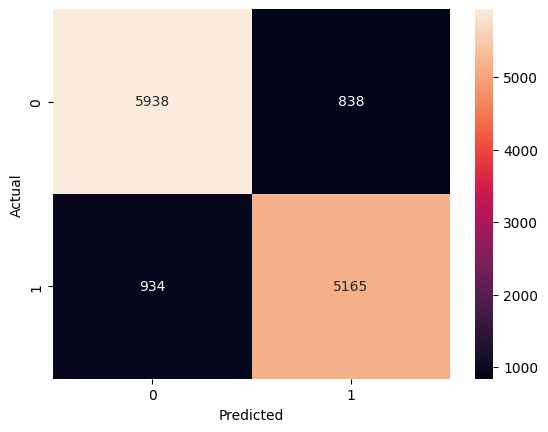

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Discussion

Several observations suggest that this dataset may be synthetic:

- Uniform feature distributions
- Extremely clean data
- Lack of missing values
- Near-perfect gradient boosting performance

Despite these limitations, the dataset remains valuable for demonstrating:

- End-to-end machine learning workflows
- Data preprocessing techniques
- Neural network implementation in PyTorch
- Model evaluation and comparison

In [71]:
results = {
    "Model": [
        "Logistic Regression",
        "ANN (PyTorch)",
        "XGBoost"
    ],
    "Accuracy": [
        0.83,
        0.91,
        1.00
    ]
}

pd.DataFrame(results)

,Model,Accuracy
0,Logistic Regression,0.83
1,ANN (PyTorch),0.91
2,XGBoost,1.00


# Conclusion

## This project successfully developed a customer churn prediction system using both classical machine learning methods and Artificial Neural Networks.

Key findings:

- Logistic Regression achieved approximately 83% accuracy.
- The PyTorch ANN improved performance to approximately 91% accuracy.
- XGBoost achieved perfect classification, indicating the dataset may be synthetic or highly separable.
